#**Hands-on previo al TP 2**

---
##**Algoritmo K-Means**

🤔 ¿Qué se puede decir de este gráfico de puntos?

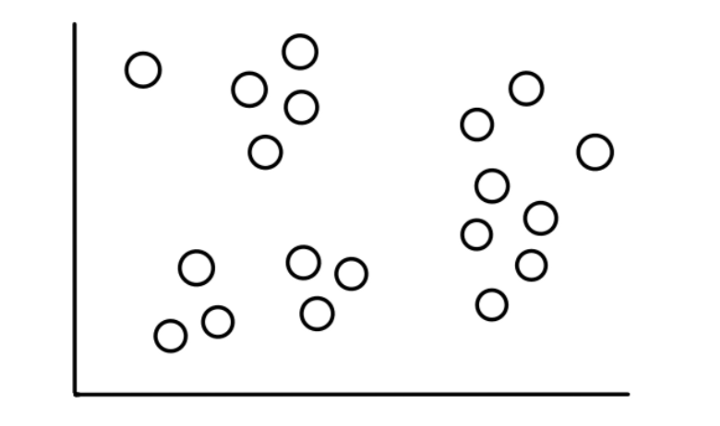

##**Algoritmo**

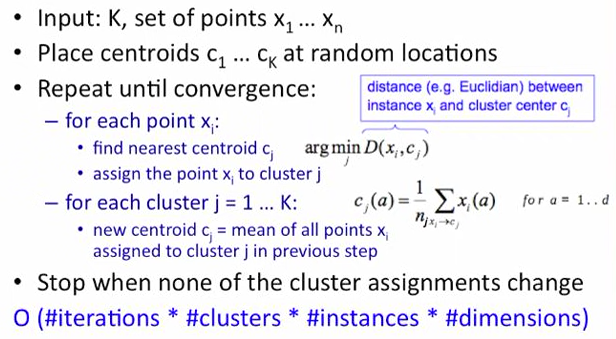

###**Corriendo el algoritmo:**

###1- Definir el número K

###2- Establecer K centroides en el espacio de los datos

###3- Generar K clusters



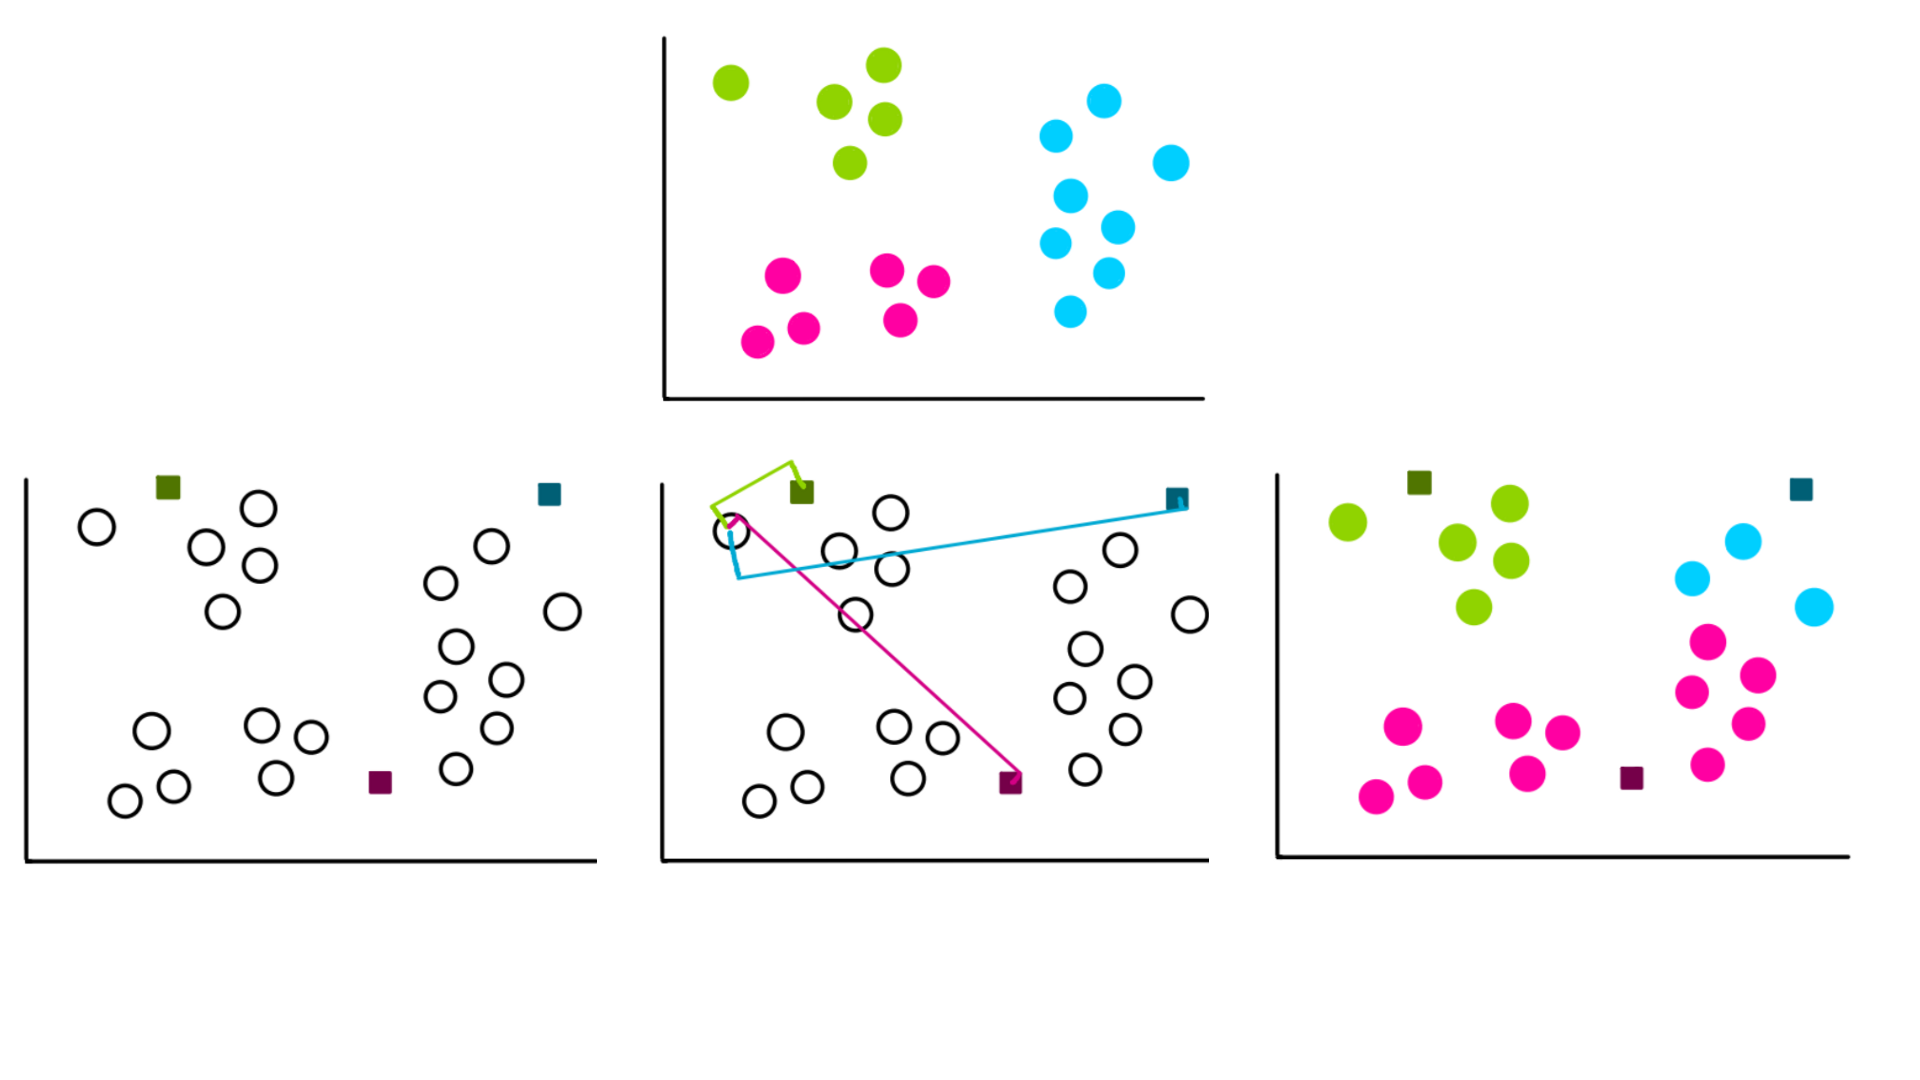

###4- Calcular el nuevo centroide para cada cluster

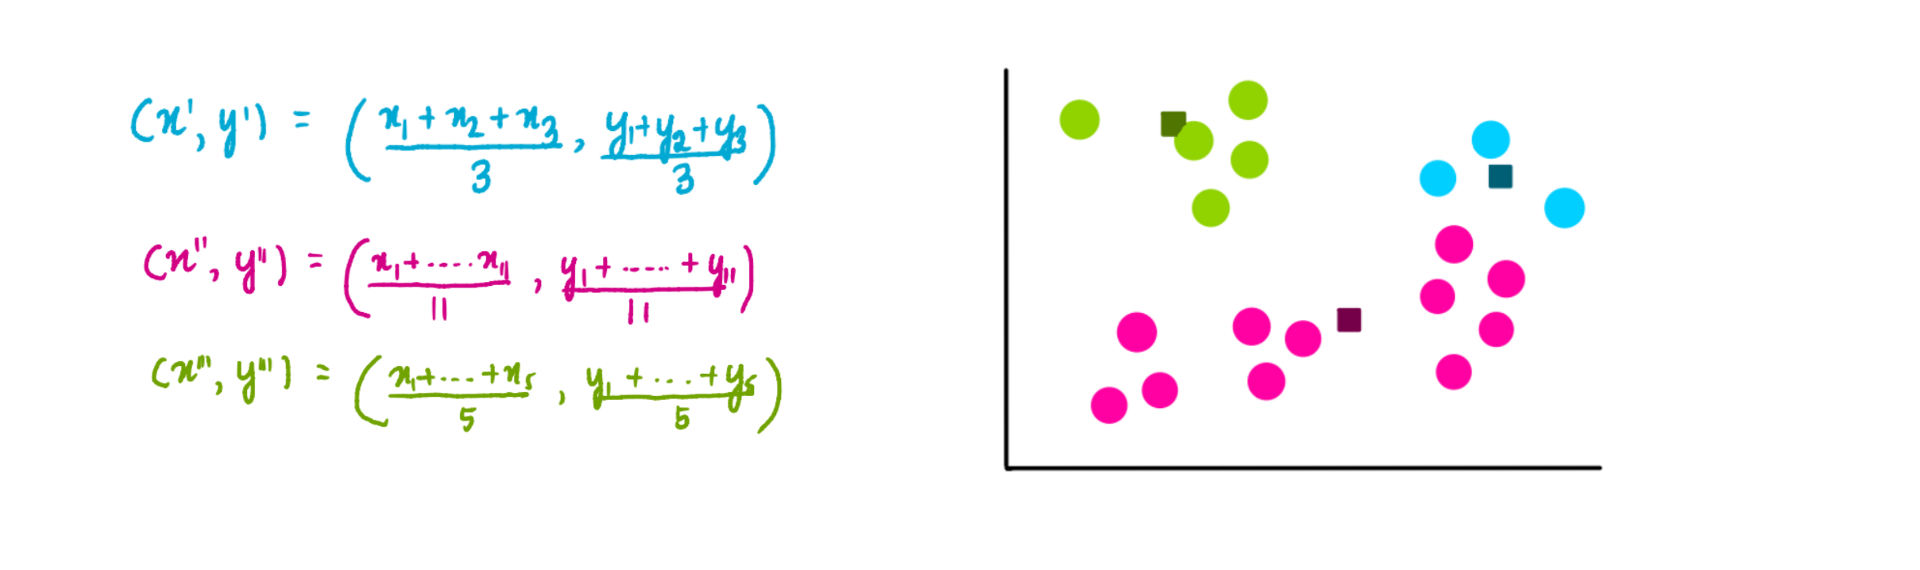

###5- Evaluar la calidad de agrupamiento de los objetos de cada grupo y repetir los pasos 3 a 5.

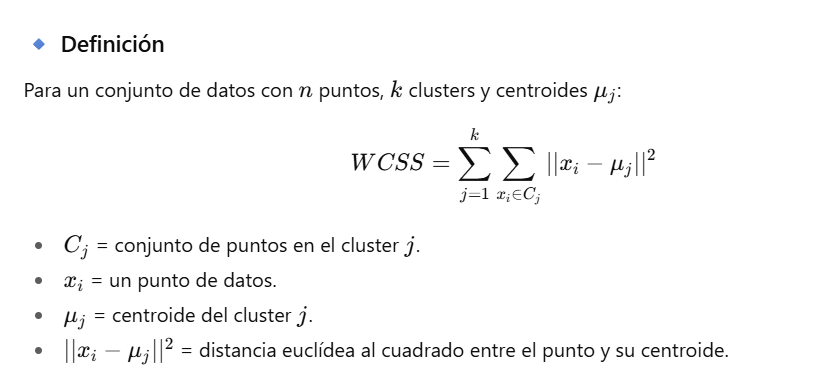

**¿Qué hace?**

Mide la compacidad de los clusters.

-  Si los puntos están muy cerca de sus centroides → WCSS bajo.

- Si los puntos están muy dispersos → WCSS alto.

Es lo que K-Means minimiza: en cada iteración, busca reducir el WCSS.

**Interpretación práctica:**

- Cuanto más bajo el WCSS, mejor (más compactos los clusters).
- Pero si aumentás mucho el número de clusters k, el WCSS siempre baja (en el extremo, si 𝑘=𝑛, cada punto es su propio cluster y el WCSS=0).

Por eso, no se puede usar WCSS solo para elegir el mejor número de clusters.
En la práctica se usa el método del codo (elbow method):

- Se grafica WCSS vs. 𝑘.
- Se busca el “codo”, donde la reducción deja de ser significativa → ese 𝑘 es un buen candidato.

###**Ejemplo completo:**

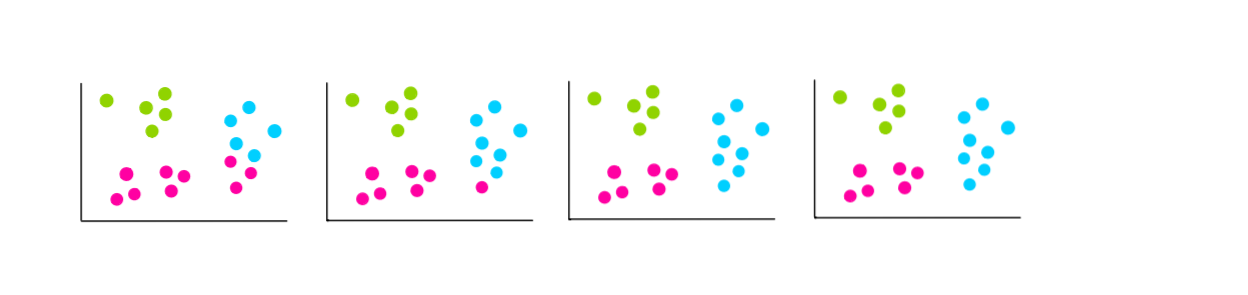

#**Algunos tips**

###**Generando datos artificiales**

In [1]:
from sklearn.datasets import make_blobs

In [6]:
features, trueLabels, centers = make_blobs(n_samples=20, centers=3, cluster_std=6, return_centers=True)

In [7]:
print(features, trueLabels)
print(features.shape, trueLabels.shape)
print(centers)

[[-14.81581761 -14.72382136]
 [ -5.96658396 -20.12597518]
 [  0.17278498  -7.97679395]
 [ 12.12718501 -12.55535754]
 [  0.8805433  -17.3563946 ]
 [  3.11521881 -11.7294671 ]
 [  7.16901259 -13.34574191]
 [ -9.99704507  -6.74726148]
 [-11.5479805  -13.62335323]
 [ -5.75055019  -7.36577868]
 [ -8.41429545 -14.09354608]
 [  2.82167372  -6.0905952 ]
 [  3.82687257  -4.26374906]
 [ -6.60829546  -4.97674391]
 [ -7.88661165 -13.73928674]
 [  6.79789897 -12.33782494]
 [-14.08494495  -6.73035761]
 [  6.3277867  -15.16007438]
 [  0.99002577  -9.48765719]
 [ -9.04429018  -3.132947  ]] [2 0 1 1 2 1 2 0 0 0 2 1 2 1 0 1 0 1 2 0]
(20, 2) (20,)
[[-9.62754348 -8.75331195]
 [ 5.7373863  -9.11668348]
 [ 0.84171456 -8.79849485]]


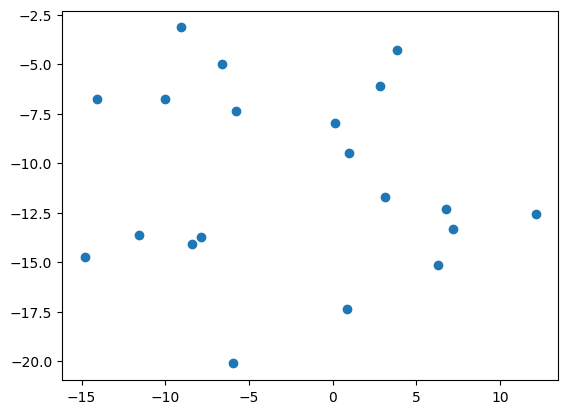

In [8]:
from matplotlib import pyplot as plt

plt.scatter(features[:,0], features[:,1])
plt.show()

In [9]:
# sumar true labes a las features
import numpy as np
trueLabels = trueLabels.reshape(-1,1)
finalData = np.hstack((features, trueLabels))
print(finalData)

[[-14.81581761 -14.72382136   2.        ]
 [ -5.96658396 -20.12597518   0.        ]
 [  0.17278498  -7.97679395   1.        ]
 [ 12.12718501 -12.55535754   1.        ]
 [  0.8805433  -17.3563946    2.        ]
 [  3.11521881 -11.7294671    1.        ]
 [  7.16901259 -13.34574191   2.        ]
 [ -9.99704507  -6.74726148   0.        ]
 [-11.5479805  -13.62335323   0.        ]
 [ -5.75055019  -7.36577868   0.        ]
 [ -8.41429545 -14.09354608   2.        ]
 [  2.82167372  -6.0905952    1.        ]
 [  3.82687257  -4.26374906   2.        ]
 [ -6.60829546  -4.97674391   1.        ]
 [ -7.88661165 -13.73928674   0.        ]
 [  6.79789897 -12.33782494   1.        ]
 [-14.08494495  -6.73035761   0.        ]
 [  6.3277867  -15.16007438   1.        ]
 [  0.99002577  -9.48765719   2.        ]
 [ -9.04429018  -3.132947     0.        ]]


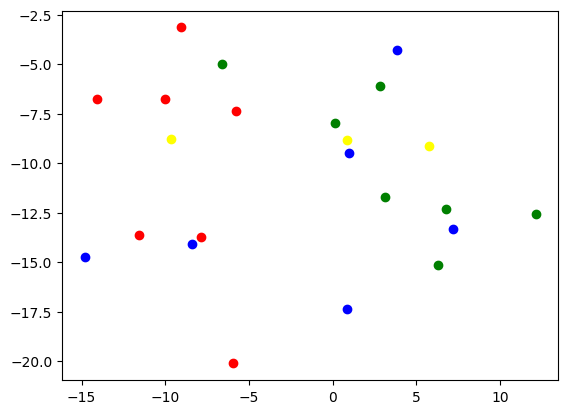

In [10]:
colors = {0:"red", 1:"green", 2:"blue"}

cluster0 = finalData[finalData[:,2] == 0]
cluster1 = finalData[finalData[:,2] == 1]
cluster2 = finalData[finalData[:,2] == 2]

plt.scatter(cluster0[:,0], cluster0[:,1], color=colors[0])
plt.scatter(cluster1[:,0], cluster1[:,1], color=colors[1])
plt.scatter(cluster2[:,0], cluster2[:,1], color=colors[2])

# add centroids
plt.scatter(centers[:,0], centers[:,1], color="yellow")

###**Enrtrenando K-Means**

In [11]:
# entrenando k-menas
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaledFeatures = scaler.fit_transform(features)


In [ ]:
print(features)
print(scaledFeatures)

[[ 10.93557895   8.21543709]
 [ 18.55075136  12.85689153]
 [  2.09303354 -19.29964158]
 [-10.69255692  -5.58366393]
 [  8.36070747  13.31807149]
 [  7.10654097   2.5632942 ]
 [  7.02641017   1.41988839]
 [  9.67089181   3.97537014]
 [  7.79713273  -3.00104115]
 [  0.79358861  -3.6346353 ]
 [  6.37848657  -8.81212126]
 [ 10.91652368   6.00536246]
 [ -1.73321804  -3.3077718 ]
 [  0.1531226   11.11346496]
 [-11.92773233 -10.60479548]
 [  3.50322165  -8.38187355]
 [ -2.60085259   2.23394335]
 [  5.49622095  -7.37702027]
 [ 11.05937448  -0.51309165]
 [  0.81904811  -7.40937914]]
[[0.75014596 0.84356247]
 [1.         0.98586106]
 [0.46002177 0.        ]
 [0.04052614 0.42050703]
 [0.66566434 1.        ]
 [0.6245151  0.67027801]
 [0.62188601 0.63522326]
 [0.70865153 0.7135697 ]
 [0.64717344 0.49968557]
 [0.41738694 0.48026072]
 [0.60062761 0.32152838]
 [0.74952075 0.77580559]
 [0.33448233 0.49028176]
 [0.39637323 0.93241076]
 [0.         0.26656823]
 [0.50629008 0.33471899]
 [0.30601521 0.6601

In [ ]:
kmeans = KMeans(n_clusters=3, verbose=2) # tol (inertia)
kmeans.fit(scaledFeatures)

Initialization complete
Iteration 0, inertia 1.0575238463240346.
Iteration 1, inertia 0.8309460536198642.
Iteration 2, inertia 0.8154818788541933.
Iteration 3, inertia 0.7962235769142217.
Converged at iteration 3: strict convergence.


KMeans(n_clusters=3, verbose=2)

In [ ]:
print(np.reshape(trueLabels, -1))
print(kmeans.labels_)

[1 1 0 2 1 1 1 1 0 0 2 1 2 2 2 0 0 0 0 2]
[1 1 2 0 1 1 1 1 2 0 2 1 0 1 0 2 0 2 1 2]


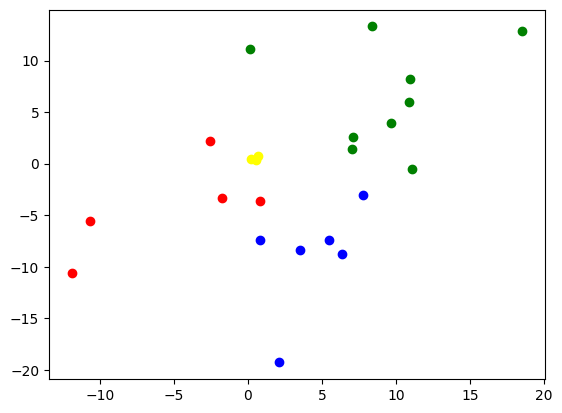

In [ ]:
# plot del resultado
colors = {0:"red", 1:"green", 2:"blue"}

cluster0 = finalData[kmeans.labels_ == 0]
cluster1 = finalData[kmeans.labels_ == 1]
cluster2 = finalData[kmeans.labels_ == 2]

plt.scatter(cluster0[:,0], cluster0[:,1], color=colors[0])
plt.scatter(cluster1[:,0], cluster1[:,1], color=colors[1])
plt.scatter(cluster2[:,0], cluster2[:,1], color=colors[2])

# add centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color="yellow")

###**Método del codo**

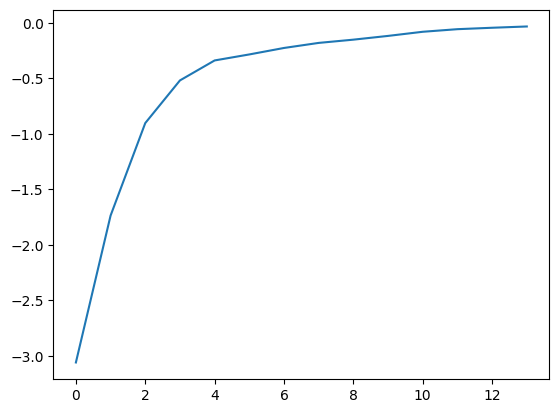

In [13]:
CANTIDAD_MAXIMA_CLUSTERS = 15
# n_init : int, default: 10 Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of n_init consecutive runs in terms of inertia.

lista_modelos = [KMeans(n_clusters=i, n_init=10) for i in range(1,CANTIDAD_MAXIMA_CLUSTERS)]
lista_scores = [modelo.fit(scaledFeatures).score(scaledFeatures) for modelo in lista_modelos]
plt.figure()
plt.plot([i for i in range(len(lista_scores))],lista_scores)

NameError: name 'kmeans' is not defined